Things I have to add for numerical data
- ~~'BOX PLOT'~~
- 'DENSITY_PLOT'
- 'CONNECTED_SCATTER PLOT'
- '3D_SCATTEROR_SURFACE'
- 'PCA'
- 'RIDGE_LINE'
- 'DENDROGRAM'
- 'SCATTER_WITH_MARGINAL_POINT'
- 'BOX_PLOT'
- 'SCATTER_PLOT'
- 'STACKED_AREA_PLOT'
- 'VIOLIN_PLOT'
- 'AREA(SM)'
- 'STREAM_GRAPH'
- 'LINE_PLOT'
- 'BUBBLE_PLOT'
- '2D_DENSITY_PLOT'
- 'HISTOGRAM'
- 'AREA_PLOT'
- 'CORRELOGRAM'
- 'HEATMAP'

In [238]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [239]:
class Boxplot:
    def __init__(self, df, x=None, y=None, hue=None, order=None, hue_order=None, 
                 orient=None, color=None, palette=None, saturation=0.75, width=0.8, dodge=True, 
                 fliersize=5, linewidth=None, whis=1.5, ax=None, title=None, no_of_obs=False, **kwargs):
        """
        This class is used to create boxplot figures using seaborn.

        Attributes:
            df (pandas.DataFrame): The dataframe containing the data to plot.
            x, y (str): The names of two columns in df. The box plots will be for the y column grouped by x column values.
            hue (str, optional): Column name for grouping the data by color/hue.
            order, hue_order (list, optional): Order to plot the categorical levels in.
            orient (str, optional): Orientation of the plot. 'v' or 'h'.
            color (str, optional): Color for all of the elements.
            palette (str, optional): Colors to use for the different levels of the hue variable.
            saturation (float, optional): Proportion of the original saturation to draw colors.
            width (float, optional): Width of a full element when not using hue nesting, or width of all the elements for one 
                        level of the major grouping variable.
            dodge (bool, optional): When hue nesting is used, whether elements should be shifted along the categorical axis.
            fliersize (float, optional): Size of the markers used to indicate outlier observations.
            linewidth (float, optional): Line width of the box outlines.
            whis (float, optional): Proportion of the IQR past the low and high quartiles to extend the plot whiskers.
            ax (matplotlib.axes, optional): Pre-existing axes for the plot. Otherwise, a new one is created.
            title (str, optional): Title for the plot.
            no_of_obs (bool, optional): Whether to show the number of observations in each box.
            **kwargs: Additional keyword arguments are passed to the underlying seaborn boxplot function. Other keyword arguments 
                        are passed through to matplotlib.axes.Axes.boxplot().

        """
        self.__df = df
        self.__x = x
        self.__y = y
        self.__hue = hue
        self.__order = order
        self.__hue_order = hue_order
        self.__orient = orient
        self.__color = color
        self.__palette = palette
        self.__saturation = saturation
        self.__width = width
        self.__dodge = dodge
        self.__fliersize = fliersize
        self.__linewidth = linewidth
        self.__whis = whis
        self.__ax = ax
        self.__title = title
        self.__no_of_obs = no_of_obs
        self.__kwargs = kwargs

        self.__plot()

    def __plot(self):
        """
        This is a private method used to create the boxplot.

        """
        if not self.__ax:
            self.__ax = sns.boxplot(x=self.__x, y=self.__y, hue=self.__hue, data=self.__df, order=self.__order, 
                        hue_order=self.__hue_order, orient=self.__orient, color=self.__color, 
                        palette=self.__palette, saturation=self.__saturation, width=self.__width, 
                        dodge=self.__dodge, fliersize=self.__fliersize, linewidth=self.__linewidth, 
                        whis=self.__whis, ax=self.__ax, **self.__kwargs)

        if self.__ax and self.__no_of_obs:
            nobs = self.__df.groupby(self.__x).size().values
            nobs = [str(x) for x in nobs.tolist()]
            nobs = ["n: " + i for i in nobs]

            pos = range(len(nobs))
            medians = self.__df.groupby(self.__x)[self.__y].median().values
            for tick, label in zip(pos, self.__ax.get_xticklabels()):
                self.__ax.text(pos[tick], medians[tick] + 0.1, nobs[tick], horizontalalignment='center', 
                             size='medium', color='black', weight='semibold')

        if self.__title:
            plt.title(self.__title)

    def save_plot(self, file_name, folder=None):
        if folder:
            if not os.path.exists(folder):
                os.makedirs(folder)
            file_name = os.path.join(folder, file_name)
        self.__plot()
        plt.savefig(file_name)
        plt.show()

In [240]:
a = pd.DataFrame({ 'group' : np.repeat('A',500), 'value': np.random.normal(10, 5, 500) })
b = pd.DataFrame({ 'group' : np.repeat('B',500), 'value': np.random.normal(13, 1.2, 500) })
c = pd.DataFrame({ 'group' : np.repeat('B',500), 'value': np.random.normal(18, 1.2, 500) })
d = pd.DataFrame({ 'group' : np.repeat('C',20), 'value': np.random.normal(25, 4, 20) })
e = pd.DataFrame({ 'group' : np.repeat('D',100), 'value': np.random.uniform(12, size=100) })
df= pd.concat([a, b, c, d], axis=0)


In [241]:

df = sns.load_dataset('iris')

In [242]:
# Boxplot(df, 'species', 'sepal_length')
# Boxplot(df, x='group', y='value', title='avbasd')

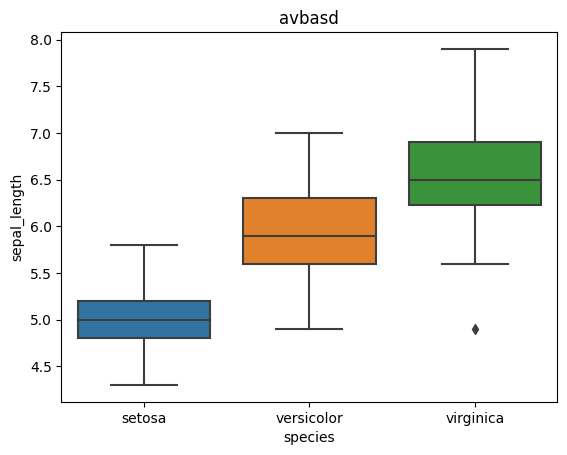

In [243]:
# asd = Boxplot(df, x='group', y='value', title='avbasd')
asd = Boxplot(df, x='species', y='sepal_length', title='avbasd')
asd.save_plot('box_plot.png')